# PX4 Phase 1 Rate Dynamics PINN Training v11 Altitude Kinematic

v11 keeps the relaxed v10 direct-delta model, but removes altitude delta from the primary neural output.

The network predicts:

```text
all dx except dx_relative_altitude_m, plus auxiliary acceleration targets
```

Altitude is reconstructed by kinematics:

```text
vel_down_next = vel_down + dx_vel_down
h_next = h - 0.5 * (vel_down + vel_down_next) * dt
```

This targets the main v10 failure mode: small one-step altitude bias accumulating into large rollout drift.


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_180000'

def find_latest_dataset_dir():
    import glob
    patterns = [
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        './px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
    ]
    matches=[]
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches=sorted(set(matches))
    matches=[Path(m) for m in matches if (Path(m)/'train.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v4/v3 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_175455
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load data and create nominal/stress split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]
feature_cols = [f'x_{c}' for c in state_cols] + [f'u_{c}' for c in action_cols] + [f'prev_u_{c}' for c in action_cols] + [f'du_{c}' for c in action_cols] + ['dt_s']
target_cols = [f'dx_{c}' for c in state_cols]
learned_target_cols = [c for c in target_cols if c != 'dx_relative_altitude_m']
next_cols = [f'x_next_{c}' for c in state_cols]
aux_cols = [
    'aux_derived_accel_north_m_s2',
    'aux_derived_accel_east_m_s2',
    'aux_derived_accel_down_m_s2',
    'aux_derived_roll_accel_rad_s2',
    'aux_derived_pitch_accel_rad_s2',
    'aux_derived_yaw_accel_rad_s2',
]
missing = [c for c in feature_cols + target_cols + next_cols + aux_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

needed = feature_cols + target_cols + next_cols + aux_cols
all_df = all_df[np.isfinite(all_df[needed].to_numpy(np.float32)).all(axis=1)].copy()

STRESS_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.14
TEST_FRACTION = 0.14
MIN_GROUP_FOR_SPLIT = 30

stress_test_df = all_df[all_df['scenario'].isin(STRESS_SCENARIOS)].copy() if 'scenario' in all_df.columns else all_df.iloc[0:0].copy()
nominal_df = all_df[~all_df['scenario'].isin(STRESS_SCENARIOS)].copy() if 'scenario' in all_df.columns else all_df.copy()

rng = np.random.default_rng(SEED)
train_idx=[]; val_idx=[]; test_idx=[]
group_cols = [c for c in ['source_run', 'scenario'] if c in nominal_df.columns]
if group_cols:
    for _, group in nominal_df.groupby(group_cols, sort=False):
        idx = group.index.to_numpy().copy(); rng.shuffle(idx)
        if len(idx) < MIN_GROUP_FOR_SPLIT:
            train_idx.extend(idx.tolist()); continue
        n_test = max(1, int(round(len(idx) * TEST_FRACTION)))
        n_val = max(1, int(round(len(idx) * VAL_FRACTION)))
        test_idx.extend(idx[:n_test].tolist())
        val_idx.extend(idx[n_test:n_test+n_val].tolist())
        train_idx.extend(idx[n_test+n_val:].tolist())
else:
    idx = nominal_df.index.to_numpy().copy(); rng.shuffle(idx)
    n_test=int(round(len(idx)*TEST_FRACTION)); n_val=int(round(len(idx)*VAL_FRACTION))
    test_idx=idx[:n_test].tolist(); val_idx=idx[n_test:n_test+n_val].tolist(); train_idx=idx[n_test+n_val:].tolist()

train_df = nominal_df.loc[sorted(train_idx)].copy()
val_df = nominal_df.loc[sorted(val_idx)].copy()
test_df = nominal_df.loc[sorted(test_idx)].copy()

print('train/val/test/stress rows:', len(train_df), len(val_df), len(test_df), len(stress_test_df))
print('state_cols:', state_cols)
print('learned_target_cols:', learned_target_cols)
print('aux_cols:', aux_cols)
print('n_features:', len(feature_cols), 'n_learned_targets:', len(learned_target_cols), 'n_full_targets:', len(target_cols), 'n_aux:', len(aux_cols))
if 'scenario' in all_df.columns:
    split_view = pd.concat([
        train_df.assign(split_view='train'),
        val_df.assign(split_view='val'),
        test_df.assign(split_view='test'),
        stress_test_df.assign(split_view='stress'),
    ])
    display(split_view.groupby(['split_view','scenario']).size().to_frame('rows').reset_index())


train/val/test/stress rows: 11368 2217 2217 1445
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
learned_target_cols: ['dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_vel_down_m_s', 'dx_roll_deg', 'dx_pitch_deg', 'dx_yaw_deg', 'dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']
aux_cols: ['aux_derived_accel_north_m_s2', 'aux_derived_accel_east_m_s2', 'aux_derived_accel_down_m_s2', 'aux_derived_roll_accel_rad_s2', 'aux_derived_pitch_accel_rad_s2', 'aux_derived_yaw_accel_rad_s2']
n_features: 23 n_learned_targets: 9 n_full_targets: 10 n_aux: 6


,split_view,scenario,rows
0,stress,N11_mixed_sequence,1445
1,test,N00_hover_hold_0p5192,168
2,test,N01_pitch_rate_doublet_5dps,196
3,test,N02_pitch_rate_doublet_10dps,191
4,test,N03_roll_rate_doublet_5dps,185
5,test,N04_roll_rate_doublet_10dps,196
6,test,N05_yaw_rate_doublet_10dps,196
7,test,N06_yaw_rate_doublet_20dps,293
8,test,N07_thrust_step_pm010,196
9,test,N08_thrust_step_pm020,196


In [4]:
# Scalers and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean=np.asarray(mean,dtype=np.float32)
        self.std=np.asarray(std,dtype=np.float32)
        self.std=np.where(self.std<1e-8,1.0,self.std)
    @classmethod
    def fit(cls, arr): return cls(np.nanmean(arr,axis=0), np.nanstd(arr,axis=0))
    def transform(self, arr): return (np.asarray(arr,dtype=np.float32)-self.mean)/self.std
    def inverse_transform(self, arr): return np.asarray(arr,dtype=np.float32)*self.std+self.mean
    def to_dict(self, columns): return {'columns':list(columns),'mean':self.mean.tolist(),'std':self.std.tolist()}

X_train_raw=train_df[feature_cols].to_numpy(np.float32); Y_train_raw=train_df[learned_target_cols].to_numpy(np.float32); Yfull_train_raw=train_df[target_cols].to_numpy(np.float32); A_train_raw=train_df[aux_cols].to_numpy(np.float32)
X_val_raw=val_df[feature_cols].to_numpy(np.float32); Y_val_raw=val_df[learned_target_cols].to_numpy(np.float32); Yfull_val_raw=val_df[target_cols].to_numpy(np.float32); A_val_raw=val_df[aux_cols].to_numpy(np.float32)
X_test_raw=test_df[feature_cols].to_numpy(np.float32); Y_test_raw=test_df[learned_target_cols].to_numpy(np.float32); Yfull_test_raw=test_df[target_cols].to_numpy(np.float32); A_test_raw=test_df[aux_cols].to_numpy(np.float32)

x_scaler=StandardScaler.fit(X_train_raw)
y_scaler=StandardScaler.fit(Y_train_raw)
yfull_scaler=StandardScaler.fit(Yfull_train_raw)
a_scaler=StandardScaler.fit(A_train_raw)

X_train=x_scaler.transform(X_train_raw); Y_train=y_scaler.transform(Y_train_raw); Yfull_train=yfull_scaler.transform(Yfull_train_raw); A_train=a_scaler.transform(A_train_raw)
X_val=x_scaler.transform(X_val_raw); Y_val=y_scaler.transform(Y_val_raw); Yfull_val=yfull_scaler.transform(Yfull_val_raw); A_val=a_scaler.transform(A_val_raw)
X_test=x_scaler.transform(X_test_raw); Y_test=y_scaler.transform(Y_test_raw); Yfull_test=yfull_scaler.transform(Yfull_test_raw); A_test=a_scaler.transform(A_test_raw)

BATCH_SIZE=1024
train_loader=DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train), torch.tensor(Yfull_train), torch.tensor(A_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader=DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val), torch.tensor(Yfull_val), torch.tensor(A_val)), batch_size=BATCH_SIZE, shuffle=False)

x_mean_t=torch.tensor(x_scaler.mean,dtype=torch.float32,device=device); x_std_t=torch.tensor(x_scaler.std,dtype=torch.float32,device=device)
y_mean_t=torch.tensor(y_scaler.mean,dtype=torch.float32,device=device); y_std_t=torch.tensor(y_scaler.std,dtype=torch.float32,device=device)
yfull_mean_t=torch.tensor(yfull_scaler.mean,dtype=torch.float32,device=device); yfull_std_t=torch.tensor(yfull_scaler.std,dtype=torch.float32,device=device)
a_mean_t=torch.tensor(a_scaler.mean,dtype=torch.float32,device=device); a_std_t=torch.tensor(a_scaler.std,dtype=torch.float32,device=device)
feature_index={c:i for i,c in enumerate(feature_cols)}; learned_target_index={c:i for i,c in enumerate(learned_target_cols)}; target_index={c:i for i,c in enumerate(target_cols)}; aux_index={c:i for i,c in enumerate(aux_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 12 3


In [5]:
# Model: direct learned dx except altitude, with auxiliary acceleration head
class AltKinematicDxAuxMLP(nn.Module):
    def __init__(self, n_in, n_dx, n_aux, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers=[]; last=n_in
        for _ in range(depth):
            layers += [nn.Linear(last,hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout>0: layers.append(nn.Dropout(dropout))
            last=hidden
        self.trunk=nn.Sequential(*layers)
        self.dx_head=nn.Linear(last,n_dx)
        self.aux_head=nn.Linear(last,n_aux)
    def forward(self,x):
        z=self.trunk(x)
        return self.dx_head(z), self.aux_head(z)

MODEL_CONFIG=dict(hidden=512, depth=5, dropout=0.02)
model=AltKinematicDxAuxMLP(len(feature_cols), len(learned_target_cols), len(aux_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


AltKinematicDxAuxMLP(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
  )
  (dx_head): Linear(in_features=512, 

In [6]:
# Weak physics losses and altitude kinematic assembly
EPOCHS=900
LR=1e-3
WEIGHT_DECAY=2e-5
PATIENCE=130
GRAD_CLIP=2.0

DATA_WEIGHT=1.0
FULL_DX_WEIGHT=0.20
AUX_WEIGHT=0.08
EULER_KIN_WEIGHT=0.030
AUX_CONSISTENCY_WEIGHT=0.025
EULER_RESID_SCALE_RAD=np.deg2rad(1.0)

LEARNED_TARGET_DATA_WEIGHTS={
    'dx_vel_down_m_s':1.15,
    'dx_yaw_deg':1.10,
    'dx_yaw_rate_rad_s':1.08,
}
FULL_TARGET_WEIGHTS={
    'dx_relative_altitude_m':1.35,
    'dx_vel_down_m_s':1.10,
    'dx_yaw_deg':1.05,
}
AUX_DATA_WEIGHTS={
    'aux_derived_accel_down_m_s2':1.10,
    'aux_derived_yaw_accel_rad_s2':1.10,
}

learned_weight_vec=torch.ones(len(learned_target_cols),dtype=torch.float32,device=device)
for name,w in LEARNED_TARGET_DATA_WEIGHTS.items():
    if name in learned_target_index: learned_weight_vec[learned_target_index[name]]=float(w)
full_weight_vec=torch.ones(len(target_cols),dtype=torch.float32,device=device)
for name,w in FULL_TARGET_WEIGHTS.items():
    if name in target_index: full_weight_vec[target_index[name]]=float(w)
aux_weight_vec=torch.ones(len(aux_cols),dtype=torch.float32,device=device)
for name,w in AUX_DATA_WEIGHTS.items():
    if name in aux_index: aux_weight_vec[aux_index[name]]=float(w)

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-5)

def smooth_l1_weighted(pred,target,weight_vec,beta=0.5):
    err=pred-target; ae=torch.abs(err)
    loss=torch.where(ae<beta,0.5*err**2/beta,ae-0.5*beta)
    return torch.mean(loss*weight_vec[None,:])

def wrap_rad(a): return torch.atan2(torch.sin(a), torch.cos(a))
def raw_feature(xb,name):
    i=feature_index[name]; return xb[:,i]*x_std_t[i]+x_mean_t[i]
def raw_learned_dx(pred_scaled,name):
    i=learned_target_index[name]; return pred_scaled[:,i]*y_std_t[i]+y_mean_t[i]

def assemble_full_dx_raw(xb,pred_learned_scaled):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    vd=raw_feature(xb,'x_vel_down_m_s')
    dvd=raw_learned_dx(pred_learned_scaled,'dx_vel_down_m_s')
    dh=-0.5*(vd+vd+dvd)*dt
    cols=[]
    for name in target_cols:
        if name=='dx_relative_altitude_m':
            cols.append(dh)
        else:
            cols.append(raw_learned_dx(pred_learned_scaled,name))
    return torch.stack(cols,dim=1)

def full_dx_scaled_from_raw(full_raw):
    return (full_raw-yfull_mean_t[None,:])/yfull_std_t[None,:]

def euler_loss(xb,full_dx_raw):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    phi=torch.deg2rad(raw_feature(xb,'x_roll_deg'))
    theta=torch.deg2rad(raw_feature(xb,'x_pitch_deg')).clamp(-1.2,1.2)
    p=raw_feature(xb,'x_roll_rate_rad_s'); q=raw_feature(xb,'x_pitch_rate_rad_s'); r=raw_feature(xb,'x_yaw_rate_rad_s')
    tan_theta=torch.tan(theta); cos_theta=torch.cos(theta).clamp_min(0.2); sin_phi=torch.sin(phi); cos_phi=torch.cos(phi)
    phi_dot=p+tan_theta*(q*sin_phi+r*cos_phi)
    theta_dot=q*cos_phi-r*sin_phi
    psi_dot=(q*sin_phi+r*cos_phi)/cos_theta
    dphi=torch.deg2rad(full_dx_raw[:,target_index['dx_roll_deg']])
    dtheta=torch.deg2rad(full_dx_raw[:,target_index['dx_pitch_deg']])
    dpsi=torch.deg2rad(full_dx_raw[:,target_index['dx_yaw_deg']])
    e=torch.stack([(dphi-phi_dot*dt)/EULER_RESID_SCALE_RAD,(dtheta-theta_dot*dt)/EULER_RESID_SCALE_RAD,wrap_rad(dpsi-psi_dot*dt)/EULER_RESID_SCALE_RAD],dim=1)
    return torch.mean(e**2)

def aux_consistency_loss(xb,pred_learned_scaled,aux_scaled_true):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    losses=[]
    pairs=[
        ('dx_vel_north_m_s','aux_derived_accel_north_m_s2'),
        ('dx_vel_east_m_s','aux_derived_accel_east_m_s2'),
        ('dx_vel_down_m_s','aux_derived_accel_down_m_s2'),
        ('dx_roll_rate_rad_s','aux_derived_roll_accel_rad_s2'),
        ('dx_pitch_rate_rad_s','aux_derived_pitch_accel_rad_s2'),
        ('dx_yaw_rate_rad_s','aux_derived_yaw_accel_rad_s2'),
    ]
    for dx_name,aux_name in pairs:
        if dx_name not in learned_target_index or aux_name not in aux_index: continue
        raw_est=raw_learned_dx(pred_learned_scaled,dx_name)/dt
        j=aux_index[aux_name]
        est_scaled=(raw_est-a_mean_t[j])/a_std_t[j]
        losses.append(torch.mean((est_scaled-aux_scaled_true[:,j])**2))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device)


epoch 0001 train=0.5434 val=0.2103 data=0.1481 full=0.1488 aux=0.1992 euler=0.0018 aux_cons=0.6569 best=0.2103@1
epoch 0025 train=0.1307 val=0.1277 data=0.0875 full=0.0958 aux=0.1186 euler=0.0003 aux_cons=0.4595 best=0.1262@24
epoch 0050 train=0.1231 val=0.1225 data=0.0831 full=0.0918 aux=0.1190 euler=0.0003 aux_cons=0.4620 best=0.1225@50
epoch 0075 train=0.1215 val=0.1230 data=0.0833 full=0.0920 aux=0.1190 euler=0.0003 aux_cons=0.4707 best=0.1214@72
epoch 0100 train=0.1188 val=0.1203 data=0.0815 full=0.0904 aux=0.1161 euler=0.0002 aux_cons=0.4568 best=0.1203@100
epoch 0125 train=0.1156 val=0.1195 data=0.0807 full=0.0898 aux=0.1148 euler=0.0003 aux_cons=0.4645 best=0.1194@118
epoch 0150 train=0.1175 val=0.1213 data=0.0823 full=0.0912 aux=0.1125 euler=0.0003 aux_cons=0.4687 best=0.1194@127
epoch 0175 train=0.1140 val=0.1214 data=0.0826 full=0.0914 aux=0.1109 euler=0.0003 aux_cons=0.4635 best=0.1194@127
epoch 0200 train=0.1119 val=0.1201 data=0.0815 full=0.0904 aux=0.1097 euler=0.0003 au

,epoch,train_loss,train_data,train_full,train_aux,train_euler,train_aux_cons,val_loss,val_data,val_full,val_aux,val_euler,val_aux_cons,lr
252,253,0.110661,0.074137,0.083356,0.109966,0.000305,0.441850,0.120673,0.082141,0.091019,0.107320,0.000326,0.469310,0.000819
253,254,0.110032,0.073656,0.082925,0.109684,0.000330,0.440234,0.119890,0.081362,0.090331,0.107704,0.000295,0.473469,0.000818
254,255,0.109861,0.073393,0.082687,0.110110,0.000340,0.444478,0.121238,0.082402,0.091236,0.107401,0.000304,0.479518,0.000817
255,256,0.110258,0.073664,0.082935,0.109982,0.000344,0.447912,0.120273,0.081654,0.090578,0.106540,0.000325,0.478812,0.000815
256,257,0.110362,0.073745,0.082997,0.109416,0.000348,0.450134,0.121377,0.082539,0.091364,0.106921,0.000300,0.480115,0.000814


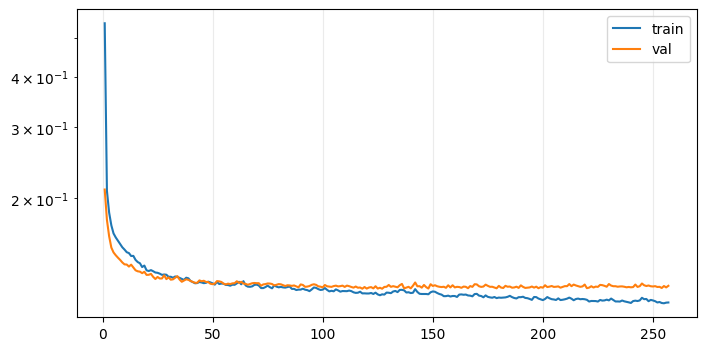

In [7]:
# Training
def run_epoch(loader,train_mode):
    model.train(train_mode)
    totals={'loss':0.0,'data':0.0,'full':0.0,'aux':0.0,'euler':0.0,'aux_cons':0.0}; n=0
    for xb,yb,yfull,ab in loader:
        xb=xb.to(device); yb=yb.to(device); yfull=yfull.to(device); ab=ab.to(device)
        if train_mode: optimizer.zero_grad(set_to_none=True)
        pred_learned,pred_aux=model(xb)
        full_raw=assemble_full_dx_raw(xb,pred_learned)
        full_scaled=full_dx_scaled_from_raw(full_raw)
        data_loss=smooth_l1_weighted(pred_learned,yb,learned_weight_vec)
        full_loss=smooth_l1_weighted(full_scaled,yfull,full_weight_vec)
        aux_loss=smooth_l1_weighted(pred_aux,ab,aux_weight_vec)
        eu_loss=euler_loss(xb,full_raw)
        aux_cons=aux_consistency_loss(xb,pred_learned,ab)
        loss=DATA_WEIGHT*data_loss + FULL_DX_WEIGHT*full_loss + AUX_WEIGHT*aux_loss + EULER_KIN_WEIGHT*eu_loss + AUX_CONSISTENCY_WEIGHT*aux_cons
        if train_mode:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); optimizer.step()
        bs=len(xb); n+=bs
        totals['loss']+=float(loss.detach().cpu())*bs; totals['data']+=float(data_loss.detach().cpu())*bs; totals['full']+=float(full_loss.detach().cpu())*bs; totals['aux']+=float(aux_loss.detach().cpu())*bs; totals['euler']+=float(eu_loss.detach().cpu())*bs; totals['aux_cons']+=float(aux_cons.detach().cpu())*bs
    return {k:v/max(1,n) for k,v in totals.items()}

best_val=float('inf'); best_state=None; best_epoch=0; wait=0; history=[]; t0=time.time()
for epoch in range(1,EPOCHS+1):
    tr=run_epoch(train_loader,True); va=run_epoch(val_loader,False); scheduler.step()
    row={'epoch':epoch,**{f'train_{k}':v for k,v in tr.items()},**{f'val_{k}':v for k,v in va.items()},'lr':scheduler.get_last_lr()[0]}; history.append(row)
    if va['loss']<best_val:
        best_val=va['loss']; best_epoch=epoch; wait=0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        wait+=1
    if epoch==1 or epoch%25==0:
        print(f"epoch {epoch:04d} train={tr['loss']:.4f} val={va['loss']:.4f} data={va['data']:.4f} full={va['full']:.4f} aux={va['aux']:.4f} euler={va['euler']:.4f} aux_cons={va['aux_cons']:.4f} best={best_val:.4f}@{best_epoch}")
    if wait>=PATIENCE:
        print('early stop at',epoch,'best_epoch=',best_epoch); break
if best_state is not None: model.load_state_dict(best_state)
hist_df=pd.DataFrame(history)
print('elapsed min:',round((time.time()-t0)/60,2),'best_epoch:',best_epoch,'best_val:',best_val)
display(hist_df.tail())
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(hist_df['epoch'],hist_df['train_loss'],label='train'); ax.plot(hist_df['epoch'],hist_df['val_loss'],label='val'); ax.set_yscale('log'); ax.grid(True,alpha=.25); ax.legend(); plt.show()


In [8]:
# One-step metrics
@torch.no_grad()
def predict_all(df):
    x=x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    dx_parts=[]; aux_parts=[]; model.eval()
    for i in range(0,len(x),4096):
        xb=torch.tensor(x[i:i+4096],dtype=torch.float32,device=device)
        pred_learned,pred_aux=model(xb)
        full_raw=assemble_full_dx_raw(xb,pred_learned)
        dx_parts.append(full_raw.detach().cpu().numpy())
        aux_parts.append(a_scaler.inverse_transform(pred_aux.detach().cpu().numpy()))
    return np.concatenate(dx_parts), np.concatenate(aux_parts)

def metric_table(split,cols,pred,true):
    rows=[]
    for j,c in enumerate(cols):
        err=pred[:,j]-true[:,j]
        if c=='dx_yaw_deg': err=(err+180)%360-180
        rows.append({'split':split,'target':c,'rmse':float(np.sqrt(np.mean(err**2))),'mae':float(np.mean(np.abs(err))),'std_true':float(np.std(true[:,j]))})
    return pd.DataFrame(rows)

parts=[]; aux_parts=[]
for split,df in [('train',train_df),('val',val_df),('test',test_df),('stress',stress_test_df)]:
    if len(df)==0: continue
    pdx,paux=predict_all(df)
    parts.append(metric_table(split,target_cols,pdx,df[target_cols].to_numpy(np.float32)))
    aux_parts.append(metric_table(split,aux_cols,paux,df[aux_cols].to_numpy(np.float32)))
metrics_df=pd.concat(parts,ignore_index=True); aux_metrics_df=pd.concat(aux_parts,ignore_index=True)
print('dx metrics with kinematic altitude'); display(metrics_df)
print('aux metrics'); display(aux_metrics_df)


dx metrics with kinematic altitude


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.006605,0.004214,0.014215
1,train,dx_vel_north_m_s,0.003517,0.001369,0.006142
2,train,dx_vel_east_m_s,0.004009,0.001632,0.006275
3,train,dx_vel_down_m_s,0.003319,0.001226,0.004371
4,train,dx_roll_deg,0.004604,0.001575,0.038966
5,train,dx_pitch_deg,0.003831,0.001377,0.036664
6,train,dx_yaw_deg,0.020698,0.005605,0.090455
7,train,dx_roll_rate_rad_s,0.001262,0.000299,0.003490
8,train,dx_pitch_rate_rad_s,0.001322,0.000309,0.003290
9,train,dx_yaw_rate_rad_s,0.000419,0.000263,0.003020


aux metrics


,split,target,rmse,mae,std_true
0,train,aux_derived_accel_north_m_s2,0.076741,0.030059,0.126517
1,train,aux_derived_accel_east_m_s2,0.089640,0.034956,0.129706
2,train,aux_derived_accel_down_m_s2,0.075626,0.025761,0.093683
3,train,aux_derived_roll_accel_rad_s2,0.044105,0.008192,0.077019
4,train,aux_derived_pitch_accel_rad_s2,0.036010,0.007845,0.064022
5,train,aux_derived_yaw_accel_rad_s2,0.011477,0.005772,0.061150
6,val,aux_derived_accel_north_m_s2,0.091585,0.028797,0.128697
7,val,aux_derived_accel_east_m_s2,0.103945,0.035688,0.141147
8,val,aux_derived_accel_down_m_s2,0.071488,0.024908,0.093486
9,val,aux_derived_roll_accel_rad_s2,0.034484,0.007742,0.065206


In [9]:
# Rollout sanity

def wrap_deg_np(x): return (x+180.0)%360.0-180.0

def make_feature_row(state_vec,action_vec,prev_action_vec,dt_s):
    return np.asarray(list(state_vec)+list(action_vec)+list(prev_action_vec)+list(action_vec-prev_action_vec)+[float(dt_s)],dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df,scenario,max_steps=None):
    sdf=df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None: sdf=sdf.iloc[:max_steps].copy()
    if len(sdf)<2: return None
    true_x=sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next=sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions=sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions=sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts=sdf['dt_s'].to_numpy(np.float32)
    x_pred=true_x[0].copy(); prev_action=prev_actions[0].copy(); pred=[]
    for k in range(len(sdf)):
        feat=make_feature_row(x_pred,actions[k],prev_action,dts[k])
        xb=torch.tensor(x_scaler.transform(feat[None,:]),dtype=torch.float32,device=device)
        pred_learned,_=model(xb)
        dx=assemble_full_dx_raw(xb,pred_learned).detach().cpu().numpy()[0]
        x_pred=x_pred+dx
        if 'yaw_deg' in state_cols: x_pred[state_cols.index('yaw_deg')]=wrap_deg_np(x_pred[state_cols.index('yaw_deg')])
        pred.append(x_pred.copy()); prev_action=actions[k].copy()
    pred=np.asarray(pred); err=pred-true_next
    if 'yaw_deg' in state_cols:
        j=state_cols.index('yaw_deg'); err[:,j]=wrap_deg_np(err[:,j])
    rows=[]
    for j,c in enumerate(state_cols): rows.append({'scenario':scenario,'state':c,'rollout_rmse':float(np.sqrt(np.mean(err[:,j]**2))),'rollout_max_abs':float(np.max(np.abs(err[:,j]))),'steps':len(sdf)})
    return pd.DataFrame(rows),sdf,pred,true_next

rollout_metrics=[]
for split_name,df in [('test',test_df),('stress',stress_test_df)]:
    for scenario in sorted(df['scenario'].unique()) if len(df) and 'scenario' in df.columns else []:
        res=rollout_scenario(df,scenario)
        if res is not None:
            m=res[0]; m.insert(0,'split',split_name); rollout_metrics.append(m)
rollout_metrics_df=pd.concat(rollout_metrics,ignore_index=True) if rollout_metrics else pd.DataFrame()
display(rollout_metrics_df)


,split,scenario,state,rollout_rmse,rollout_max_abs,steps
0,test,N00_hover_hold_0p5192,relative_altitude_m,3.861365,8.856324,168
1,test,N00_hover_hold_0p5192,vel_north_m_s,0.203708,0.388200,168
2,test,N00_hover_hold_0p5192,vel_east_m_s,0.174445,0.495748,168
3,test,N00_hover_hold_0p5192,vel_down_m_s,0.324772,0.581231,168
4,test,N00_hover_hold_0p5192,roll_deg,0.235890,0.476206,168
...,...,...,...,...,...,...
115,stress,N11_mixed_sequence,pitch_deg,7.860013,14.214660,1445
116,stress,N11_mixed_sequence,yaw_deg,9.506227,19.628098,1445
117,stress,N11_mixed_sequence,roll_rate_rad_s,0.024283,0.049536,1445
118,stress,N11_mixed_sequence,pitch_rate_rad_s,0.046884,0.101109,1445


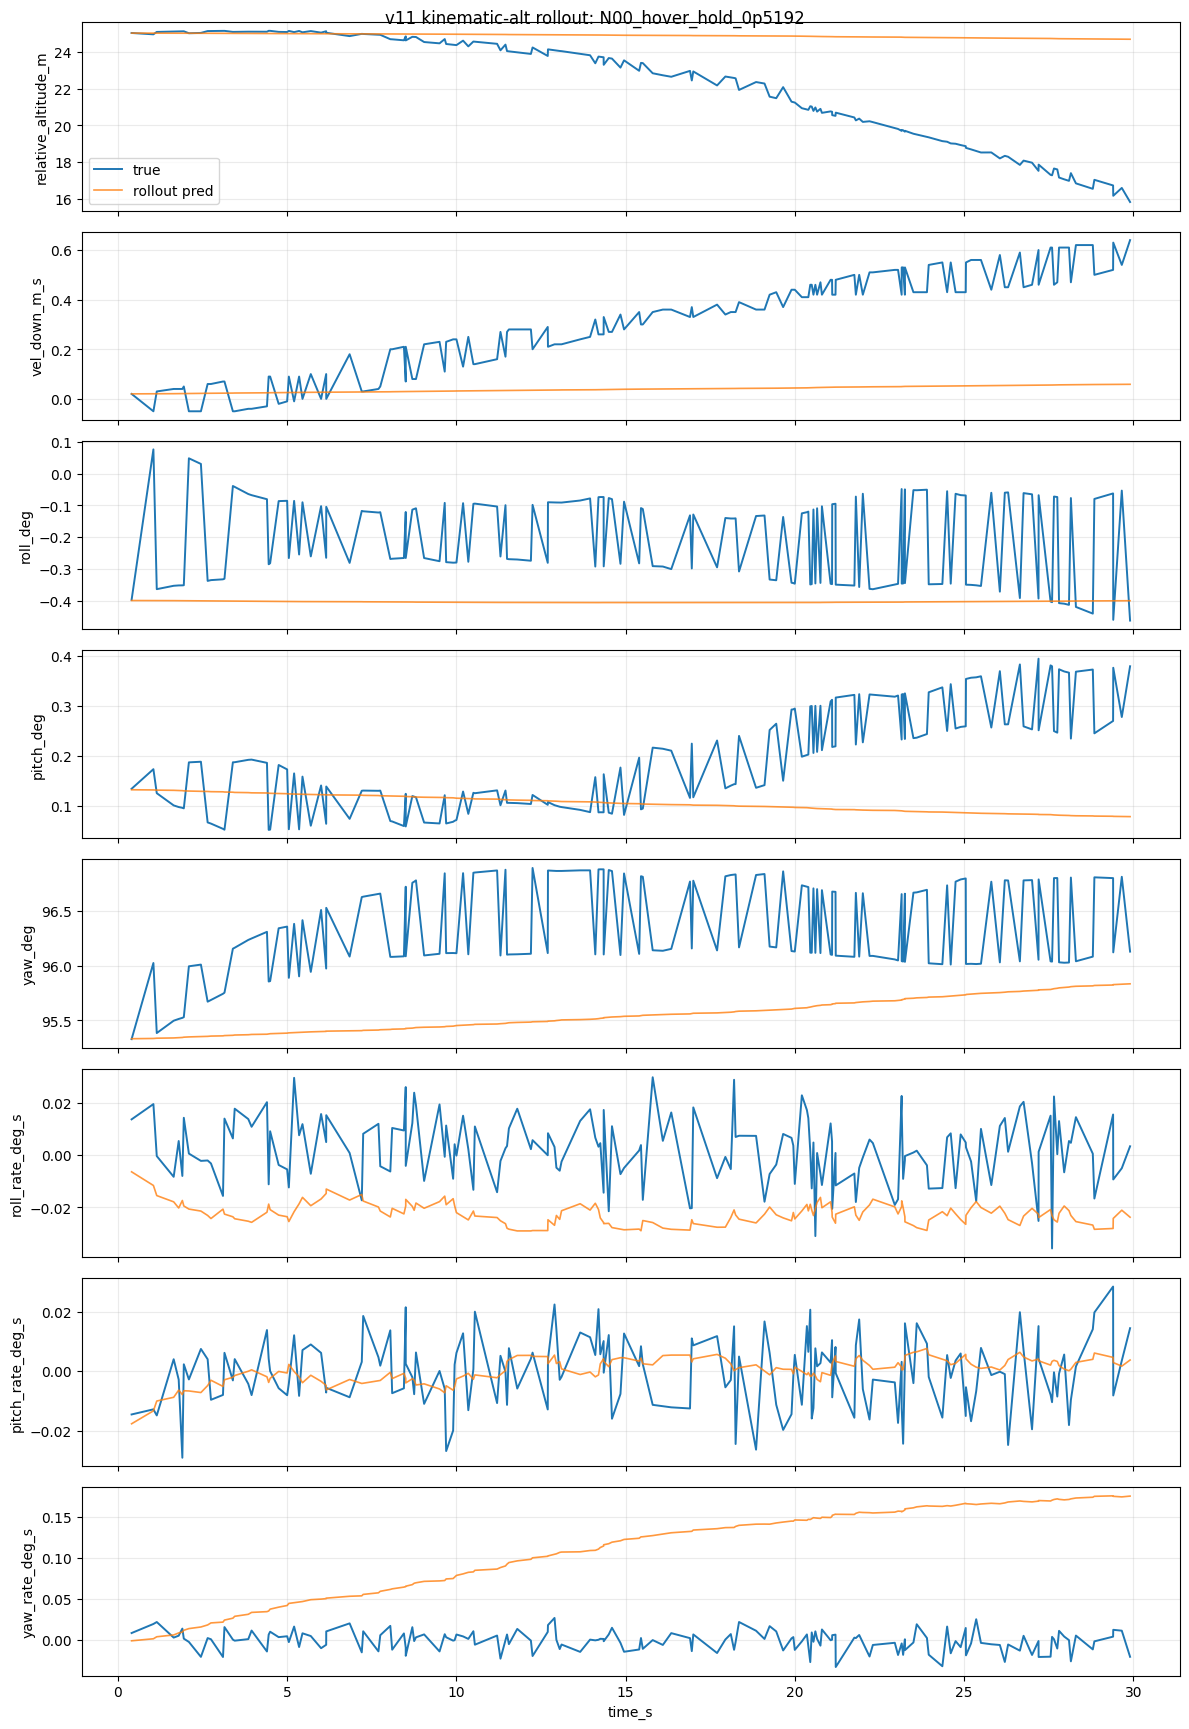

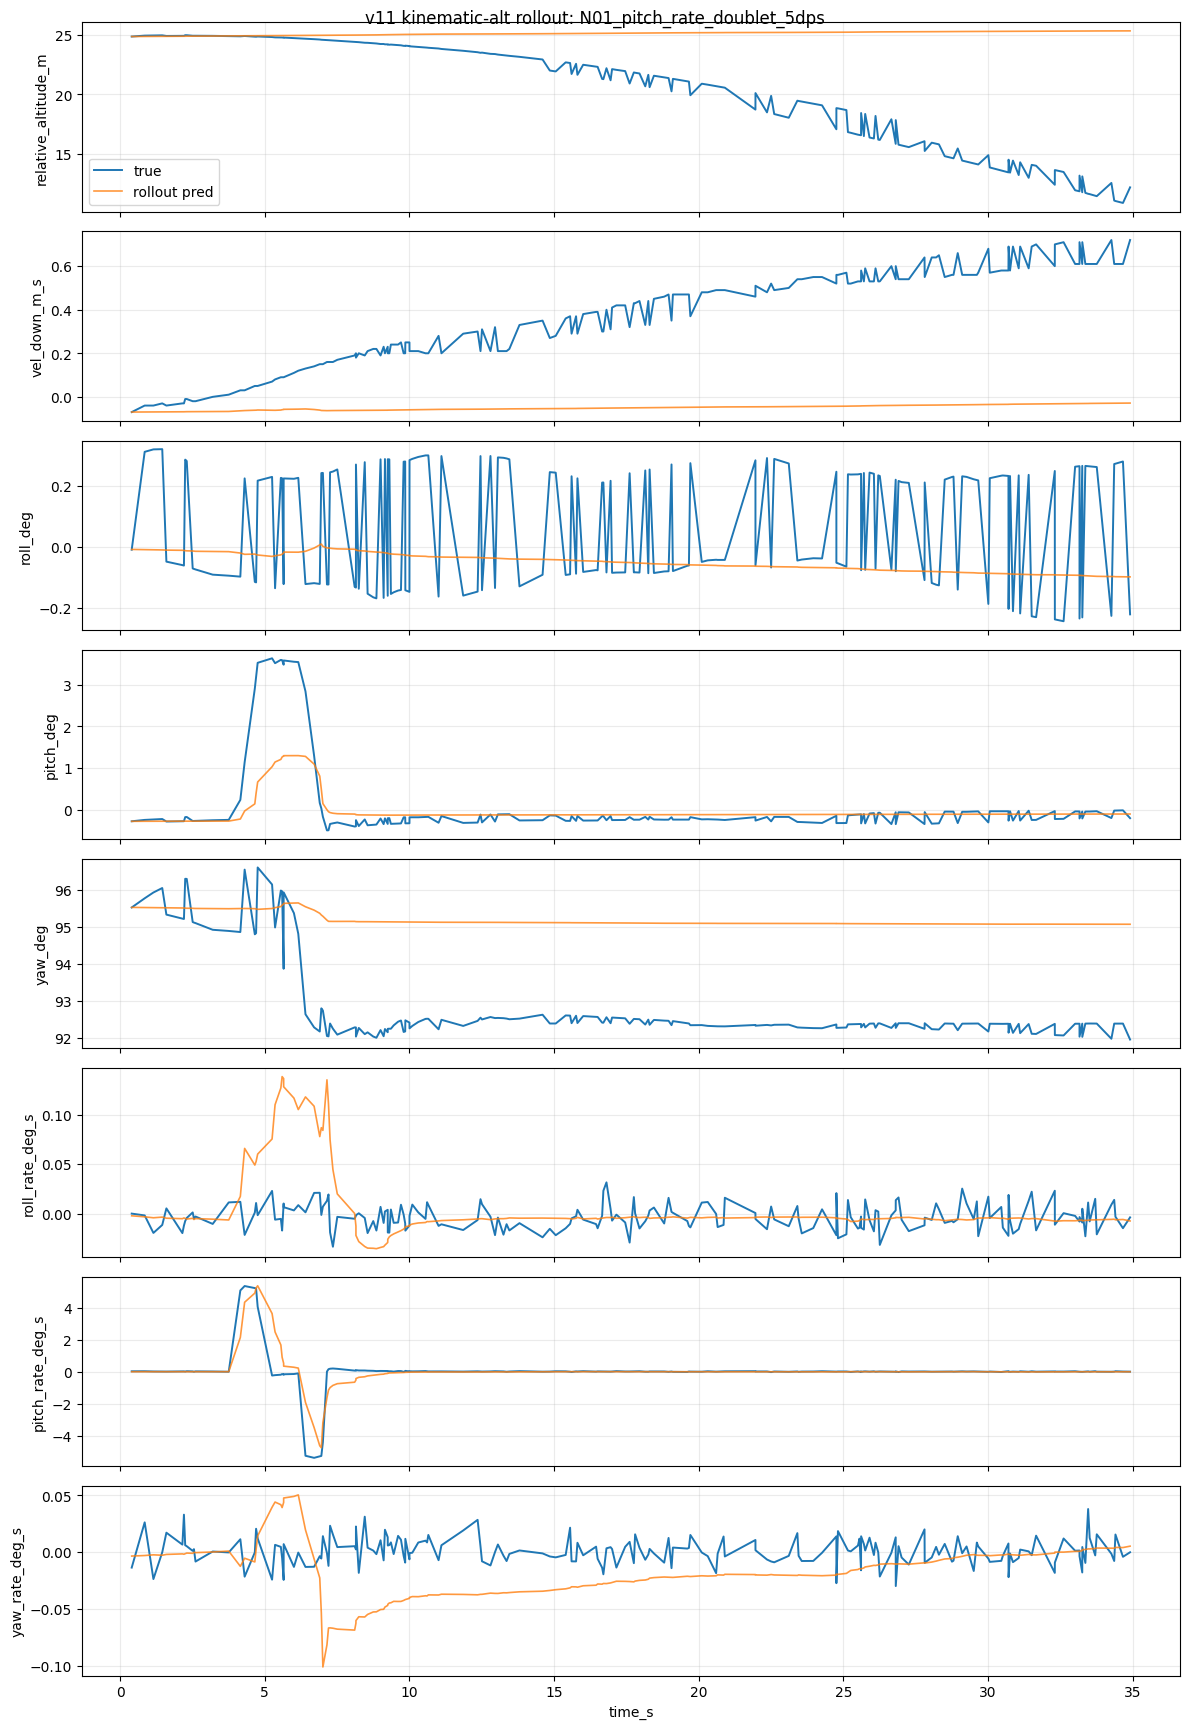

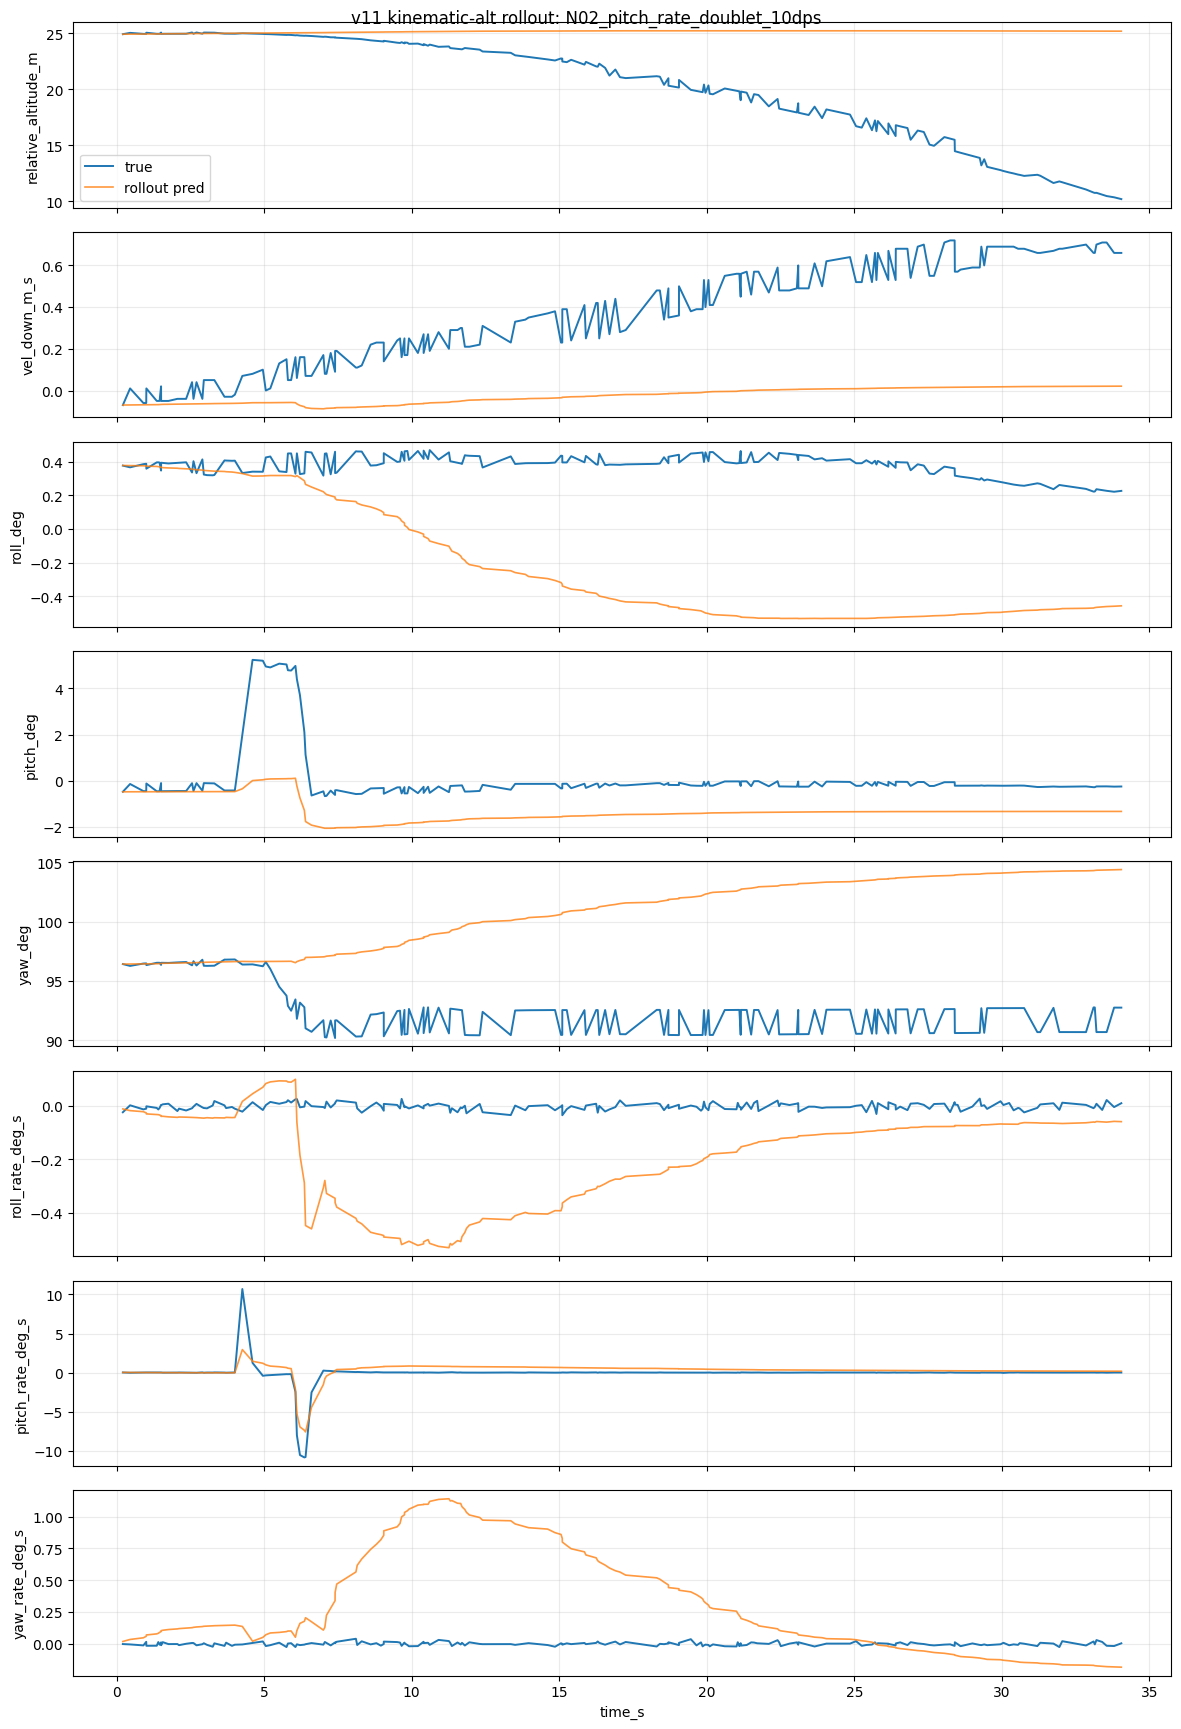

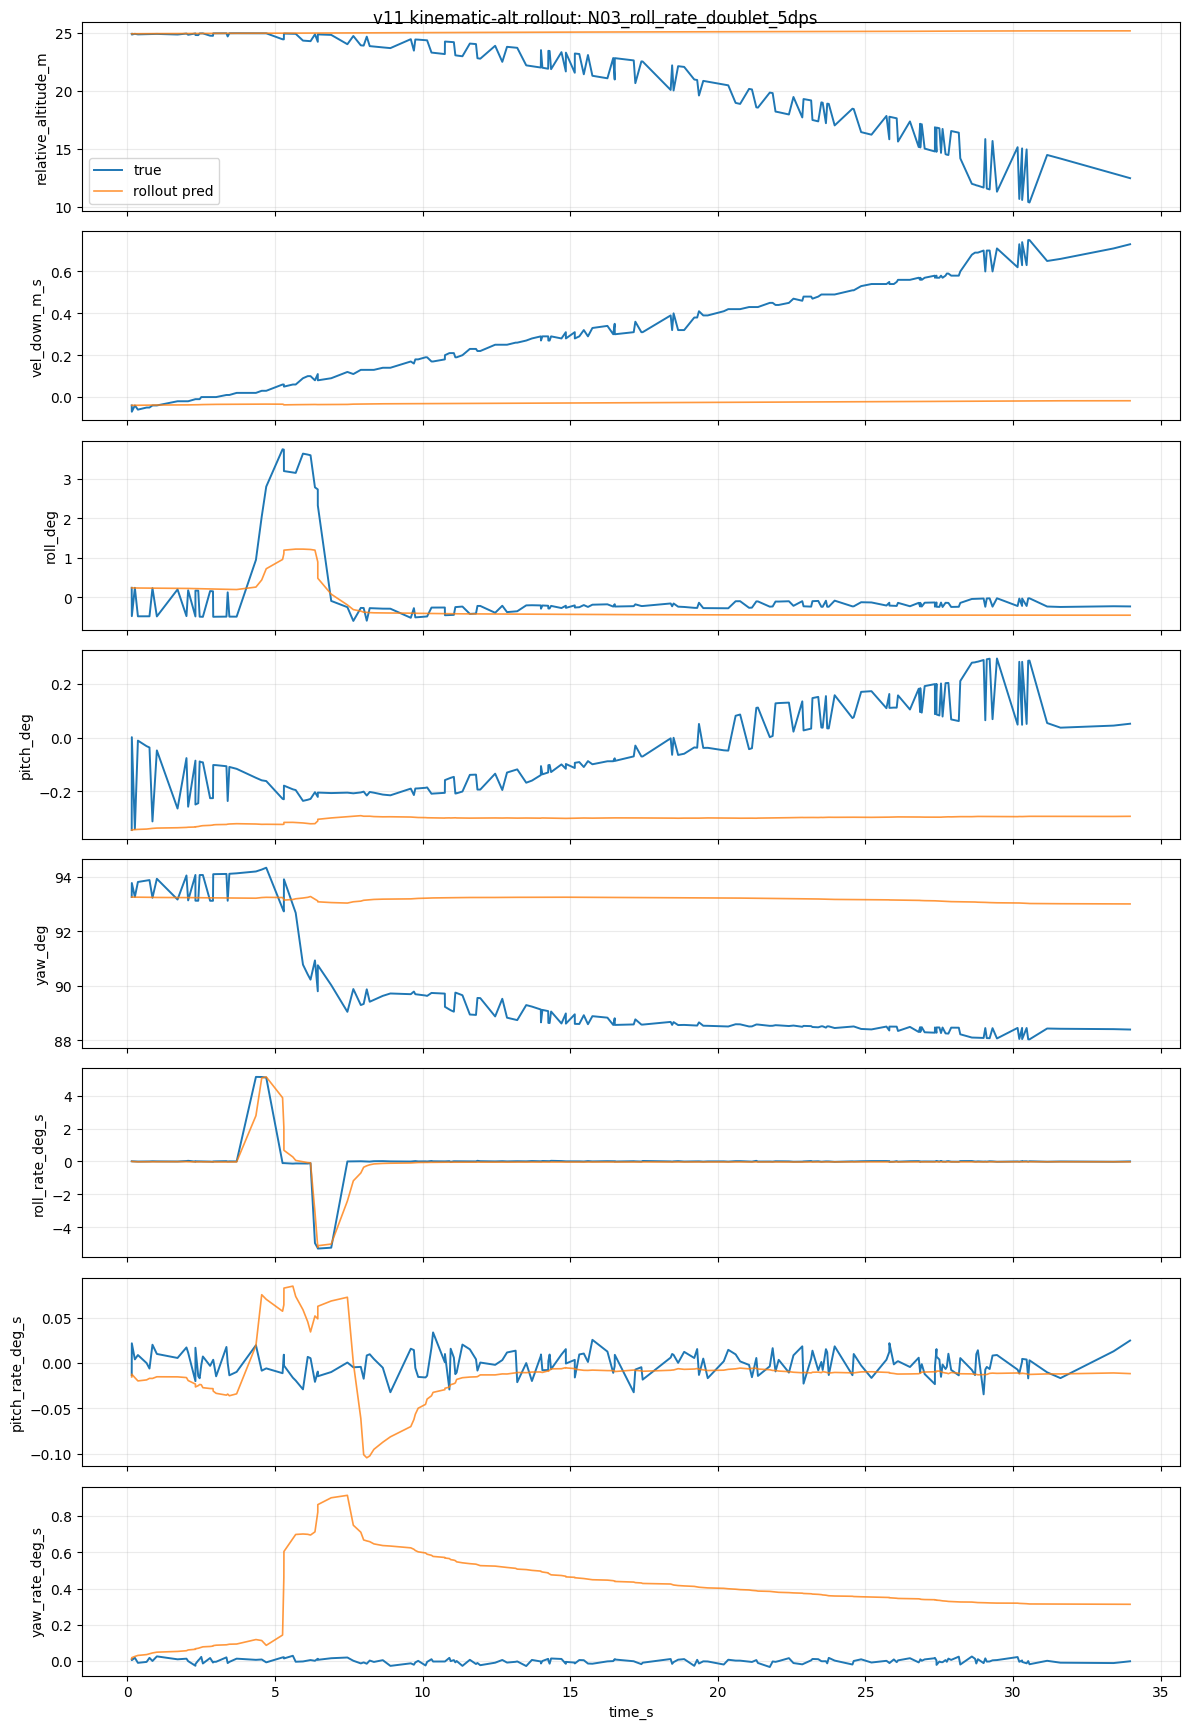

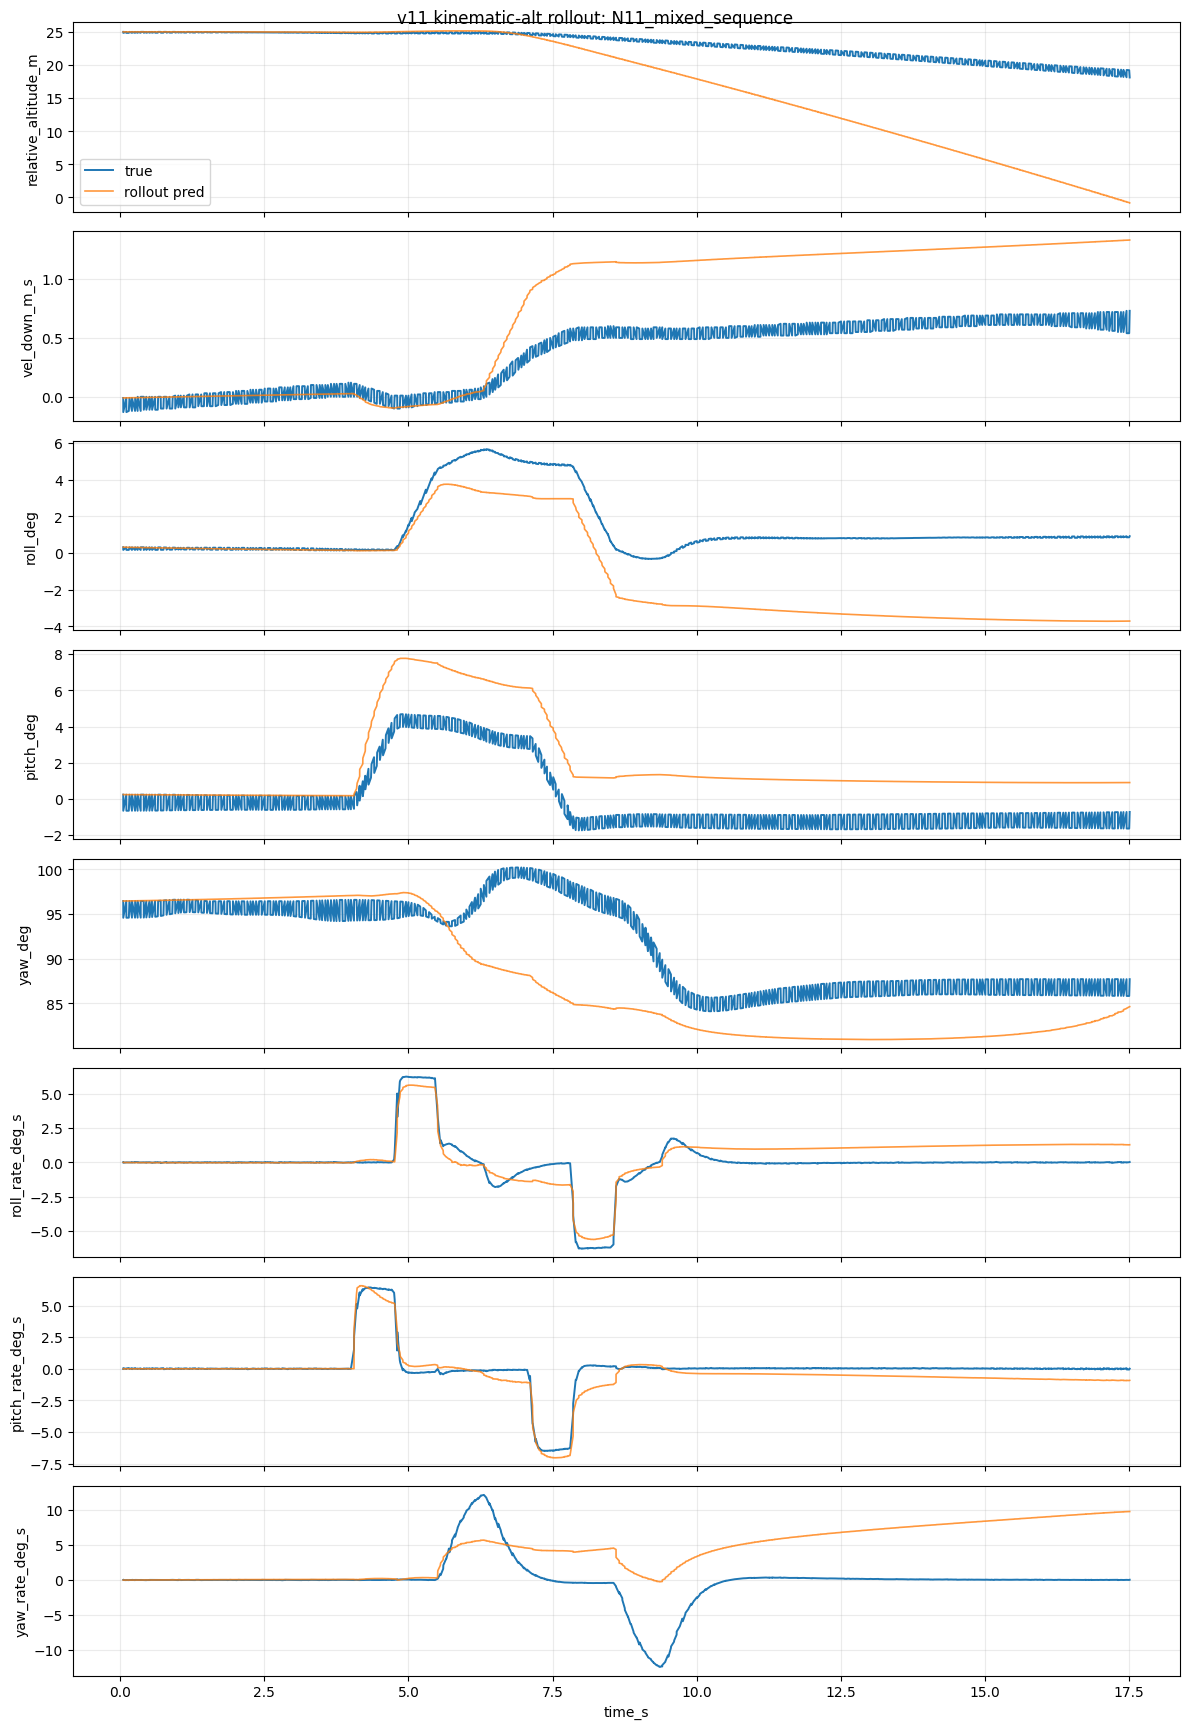

In [10]:
# Plot selected rollouts

def plot_rollout(df,scenario,max_steps=700):
    res=rollout_scenario(df,scenario,max_steps=max_steps)
    if res is None:
        print('not enough rows',scenario); return
    _,sdf,pred,true_next=res; t=sdf['time_s'].to_numpy()
    plot_states=[s for s in ['relative_altitude_m','vel_down_m_s','roll_deg','pitch_deg','yaw_deg','roll_rate_rad_s','pitch_rate_rad_s','yaw_rate_rad_s'] if s in state_cols]
    fig,axes=plt.subplots(len(plot_states),1,figsize=(12,2.2*len(plot_states)),sharex=True)
    if len(plot_states)==1: axes=[axes]
    for ax,state in zip(axes,plot_states):
        j=state_cols.index(state); yt=true_next[:,j]; yp=pred[:,j]
        label=state
        if state.endswith('_rad_s'):
            yt=np.rad2deg(yt); yp=np.rad2deg(yp); label=state.replace('_rad_s','_deg_s')
        ax.plot(t,yt,label='true',lw=1.4); ax.plot(t,yp,label='rollout pred',lw=1.2,alpha=.8); ax.set_ylabel(label); ax.grid(True,alpha=.25)
    axes[0].legend(); axes[-1].set_xlabel('time_s'); fig.suptitle(f'v11 kinematic-alt rollout: {scenario}'); plt.tight_layout(); plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]: plot_rollout(test_df,scenario)
if len(stress_test_df) and 'N11_mixed_sequence' in set(stress_test_df['scenario']): plot_rollout(stress_test_df,'N11_mixed_sequence')


In [11]:
# Save checkpoint
SAVE_ROOT=Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH/'models'
SAVE_ROOT.mkdir(parents=True,exist_ok=True)
stamp=time.strftime('%Y%m%d_%H%M%S')
ckpt_path=SAVE_ROOT/f'px4_phase1_rate_dynamics_mlp_v11_alt_kinematic_{stamp}.pt'
checkpoint={
    'model_version':'px4_phase1_rate_dynamics_mlp_v11_alt_kinematic',
    'state_dict':model.state_dict(),
    'model_config':{'n_in':len(feature_cols),'n_out':len(learned_target_cols),'n_aux':len(aux_cols),**MODEL_CONFIG},
    'feature_cols':feature_cols,'target_cols':target_cols,'learned_target_cols':learned_target_cols,'aux_cols':aux_cols,'state_cols':state_cols,'action_cols':action_cols,
    'x_scaler':x_scaler.to_dict(feature_cols),'y_scaler':y_scaler.to_dict(learned_target_cols),'yfull_scaler':yfull_scaler.to_dict(target_cols),'aux_scaler':a_scaler.to_dict(aux_cols),
    'loss_config':{'data_weight':DATA_WEIGHT,'full_dx_weight':FULL_DX_WEIGHT,'aux_weight':AUX_WEIGHT,'euler_kin_weight':EULER_KIN_WEIGHT,'aux_consistency_weight':AUX_CONSISTENCY_WEIGHT,'stress_scenarios':STRESS_SCENARIOS,'altitude_update':'kinematic_from_predicted_dx_vel_down'},
    'dataset_path':str(DATASET_PATH),'metadata':metadata,'history':hist_df.to_dict(orient='records'),'one_step_metrics':metrics_df.to_dict(orient='records'),'aux_metrics':aux_metrics_df.to_dict(orient='records'),'rollout_metrics':rollout_metrics_df.to_dict(orient='records')
}
torch.save(checkpoint,ckpt_path)
print('saved:',ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v11_alt_kinematic_20260508_092348.pt


In [12]:
# Minimal load check
loaded=torch.load(ckpt_path,map_location='cpu')
print('loaded keys:',sorted(loaded.keys()))
print('feature/learned_target/full_target/aux:',len(loaded['feature_cols']),len(loaded['learned_target_cols']),len(loaded['target_cols']),len(loaded['aux_cols']))


loaded keys: ['action_cols', 'aux_cols', 'aux_metrics', 'aux_scaler', 'dataset_path', 'feature_cols', 'history', 'learned_target_cols', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler', 'yfull_scaler']
feature/learned_target/full_target/aux: 23 9 10 6
